# **Basic Settings**

In [1]:
import os

def find_file(base_path, filename):
    for root, dirs, files in os.walk(base_path):
        if filename in files:
            return root
    return None

BASE_PATH = find_file("./", "train.csv")

print("Using path:", BASE_PATH)
os.chdir(BASE_PATH)

Using path: ./


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

from xgboost import XGBRegressor

In [3]:
import os
print(os.listdir())

['260402_ML.ipynb', 'sample_submission.csv', 'submission.csv', 'test.csv', 'train.csv', '_260402_ML.ipynb', '_sample_submission.csv', '_test.csv', '_train.csv']


# **1. Data Analysis and Basic Preprocessing for float**
## **(1) How to handle float values** : *rider_rating Column*

i. Data Load **(! Fill in Blank (########) !)**

In [4]:
import pandas as pd

df = pd.read_csv("test.csv")

# Select rider_rating column
rating = df["rider_rating"]      # Replace the ###### part

# Verification
rating.head()

0    4.5
1    4.3
2    4.9
3    4.3
4    4.7
Name: rider_rating, dtype: float64

ii. Missing value Verification

In [5]:
# Numb. of missing value
num_missing = rating.isna().sum()

# Ratio regarding to the numb. of total data
missing_ratio = rating.isna().mean()

print(f"Missing count: {num_missing}")
print(f"Missing ratio: {missing_ratio:.4f}")

Missing count: 109
Missing ratio: 0.0439


iii. Column Analysis

In [6]:
print(rating.describe())

count    2375.000000
mean        4.638316
std         0.325841
min         1.000000
25%         4.500000
50%         4.700000
75%         4.900000
max         6.000000
Name: rider_rating, dtype: float64


## **(2) Distribution Analysis** : *rider_rating Column*

i. Histogram Plot **(! Fill in Blank (########) !)**

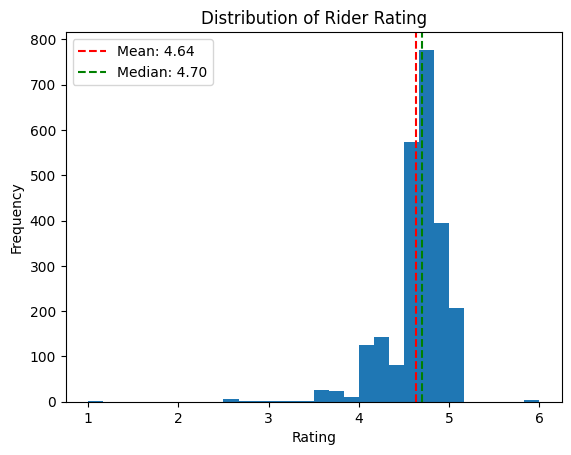

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Load
df = pd.read_csv("test.csv")
rating = df["rider_rating"].dropna()

# mean, median calculation
mean_val = rating.mean()          # Replace the ###### part
median_val = rating.median()      # Replace the ###### part

# Histogram
plt.figure()
plt.hist(rating, bins=30)       # Replace the ###### part

# Add mean, median line
plt.axvline(mean_val,color='r', linestyle='--', label=f"Mean: {mean_val:.2f}")
plt.axvline(median_val,color='g', linestyle='--', label=f"Median: {median_val:.2f}")

# Title & Lables
plt.title("Distribution of Rider Rating")
plt.xlabel("Rating")
plt.ylabel("Frequency")

# Legend plot
plt.legend()

plt.show()

ii. Box Plot **(! Fill in Blank (########) !)**

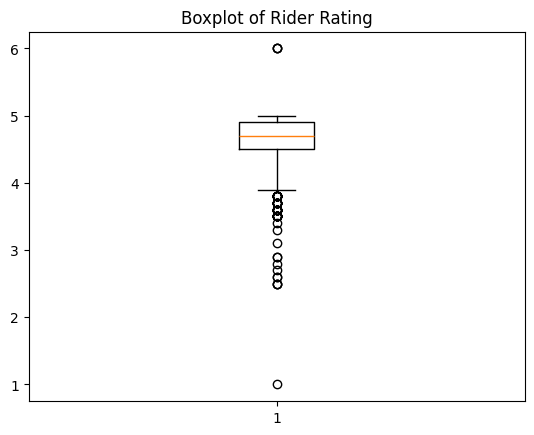

In [8]:
plt.figure()
plt.boxplot(rating.dropna(), vert=True)    # Replace the ###### part

plt.title("Boxplot of Rider Rating")

plt.show()

## **(3) Median Imputation + Missing Indicator** : *rider_rating Column*

i. Implementation **(! Fill in Blank (########) !)**

In [9]:
import pandas as pd

# Data Load
df = pd.read_csv("test.csv")

# Copy rider_rating Column
df_model = df[["rider_rating"]].copy()

# 1) Generate missing indicator
df_model["rider_rating_missing"] = df_model["rider_rating"].fillna(0).astype(int)      # Replace the ###### part

# 2) median calculation
median_rating = df_model["rider_rating"].median()

# 3) median imputation
df_model["rider_rating_imputed"] = df_model["rider_rating"].fillna(median_rating)

print(df_model.head(20))
print(f"Median used for imputation: {median_rating:.2f}")

    rider_rating  rider_rating_missing  rider_rating_imputed
0            4.5                     4                   4.5
1            4.3                     4                   4.3
2            4.9                     4                   4.9
3            4.3                     4                   4.3
4            4.7                     4                   4.7
5            NaN                     0                   4.7
6            4.6                     4                   4.6
7            4.6                     4                   4.6
8            4.6                     4                   4.6
9            4.7                     4                   4.7
10           4.7                     4                   4.7
11           4.4                     4                   4.4
12           4.7                     4                   4.7
13           4.8                     4                   4.8
14           4.9                     4                   4.9
15           4.9        

# **2. Data Analysis and Basic Preprocessing for string**

## **(1) Find Unique Categories** : *weather Column*

i. Data Load and Check the Missing Values **(! Fill in Blank (########) !)**

In [10]:
import pandas as pd

# Data Load
df = pd.read_csv("test.csv")

# Get weather Column
weather = df["weather"]            # Replace the ###### part

# 1. Find Unique Categories in weather Column (including NaN)
print("Unique categories (including NaN):")
print(weather.unique())

# 2. Find the numb. of data in each Category (including NaN)
print("\nValue counts (including NaN):")
print(weather.value_counts(dropna=False))

# 3. Number of missing values
num_missing = weather.isna().sum()
print(f"\nMissing count: {num_missing}")

Unique categories (including NaN):
['clear_sky' 'high_wind' 'foggy' 'sandstorm' nan 'overcast' 'storm']

Value counts (including NaN):
weather
sandstorm    431
foggy        424
high_wind    410
overcast     399
storm        397
clear_sky    387
NaN           36
Name: count, dtype: int64

Missing count: 36


## **(2) Mode Imputation + One Hot Encoding (OHE)** : *weather Column*

i. OHE Implementation **(! Fill in Blank (########) !)**

In [11]:
import pandas as pd

# Data Load
df = pd.read_csv("test.csv")

# Copy weather Column
weather_df = df[["weather"]].copy()

# 1. Find Mode
mode_weather = weather_df["weather"].mode()[0]
print(f"Mode used for imputation: {mode_weather}")

# 2. Replace the missing values as mode
weather_df["weather"] = weather_df["weather"].fillna(mode_weather)

# 3. One-Hot Encoding
weather_ohe = pd.get_dummies(weather_df["weather"], prefix="weather")       # Replace the ###### part

# 4. Check the Result
print("\nEncoded features:")
print(weather_ohe.head())

print("\nShape:", weather_ohe.shape)

Mode used for imputation: sandstorm

Encoded features:
   weather_clear_sky  weather_foggy  weather_high_wind  weather_overcast  \
0               True          False              False             False   
1              False          False               True             False   
2              False           True              False             False   
3              False          False              False             False   
4              False          False              False             False   

   weather_sandstorm  weather_storm  
0              False          False  
1              False          False  
2              False          False  
3               True          False  
4               True          False  

Shape: (2484, 6)


# **3. Model Overview : XGBoost**

## **(1) Grid Search in XGBoost** : *rider_rating & weather Column*

In [12]:
import pandas as pd
import numpy as np
from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from xgboost import XGBRegressor

# ==========================
# 0. FILE PATH / Column NAME
# ==========================
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
SAMPLE_SUB_PATH = "sample_submission.csv"
OUTPUT_SUB_PATH = "submission.csv"

CAT_COL = "weather"
NUM_COL = "rider_rating"
TARGET_COL = "delivery_time"

ID_COL_CANDIDATES = ["id", "ID", "Id"]

# =========================
# 1. Data Load
# =========================
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train shape:", train_df.shape)
print("test shape :", test_df.shape)

# ============================================================
# 2. Get only 2 Columns (rider_rating, weather) for Prediction
# ============================================================
train_model = train_df[[CAT_COL, NUM_COL, TARGET_COL]].copy()
train_model = train_model.dropna(subset=[TARGET_COL]).reset_index(drop=True)

# =====================================
# 3. Calculate Statistics for train.csv
# =====================================
median_num = train_model[NUM_COL].median()
mode_cat = train_model[CAT_COL].mode()[0]

print(f"Median used for {NUM_COL}: {median_num:.4f}")
print(f"Mode used for {CAT_COL}: {mode_cat}")

# ==========================
# 4. train.csv Preprocessing
# ==========================
train_model[f"{NUM_COL}_missing"] = train_model[NUM_COL].isna().astype(int)
train_model[f"{NUM_COL}_imputed"] = train_model[NUM_COL].fillna(median_num)

train_model[CAT_COL] = train_model[CAT_COL].fillna(mode_cat)
train_cat_ohe = pd.get_dummies(train_model[CAT_COL], prefix=CAT_COL, dtype=int)

X = pd.concat(
    [
        train_model[[f"{NUM_COL}_imputed", f"{NUM_COL}_missing"]],
        train_cat_ohe
    ],
    axis=1
)
y = train_model[TARGET_COL]

print("\nFeature columns:")
print(X.columns.tolist())
print("X shape:", X.shape)

# =========================
# 5. Validation split
# =========================
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =============================
# 6. Set Grid Search Parameters
# =============================
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3]
}

# ============================
# 7. Make all the Combinations
# ============================
param_names = list(param_grid.keys())
param_combinations = list(product(*param_grid.values()))

print(f"\nTotal combinations: {len(param_combinations)}")

# =========================
# 8. Implement Grid Search
# =========================
results = []

for idx, values in enumerate(param_combinations, start=1):
    params = dict(zip(param_names, values))

    model = XGBRegressor(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        min_child_weight=params["min_child_weight"],
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_valid = model.predict(X_valid)
    mape = mean_absolute_percentage_error(y_valid, pred_valid)

    result_row = params.copy()
    result_row["valid_mape"] = mape
    results.append(result_row)

    print(f"[{idx:03d}/{len(param_combinations)}] "
          f"MAPE={mape:.6f} | {params}")

# DataFrame Result
results_df = pd.DataFrame(results).sort_values("valid_mape").reset_index(drop=True)

# =========================
# 9. Print the Result
# =========================
print("\n" + "="*60)
print("Best parameter combination")
print("="*60)
print(results_df.iloc[0])

print("\n" + "="*60)
print("Top 3 parameter combinations")
print("="*60)
print(results_df.head(3))


train shape: (9939, 19)
test shape : (2484, 18)
Median used for rider_rating: 4.7000
Mode used for weather: foggy

Feature columns:
['rider_rating_imputed', 'rider_rating_missing', 'weather_clear_sky', 'weather_foggy', 'weather_high_wind', 'weather_overcast', 'weather_sandstorm', 'weather_storm']
X shape: (9939, 8)

Total combinations: 216
[001/216] MAPE=0.283438 | {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1}
[002/216] MAPE=0.283438 | {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3}
[003/216] MAPE=0.282672 | {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_weight': 1}
[004/216] MAPE=0.282672 | {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 0.8, 'colsample_bytree': 1.0, 'min_child_weight': 3}
[005/216] MAPE=0.283461 | {'n_estimators': 100

## **(2) Submission with XGBoost** : *rider_rating & weather Column*

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from xgboost import XGBRegressor

# ==========================
# 0. DATA PATH & Column NAME
# ==========================
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
SAMPLE_SUB_PATH = "sample_submission.csv"
OUTPUT_SUB_PATH = "submission.csv"

CAT_COL = "weather"
NUM_COL = "rider_rating"
TARGET_COL = "delivery_time"

ID_COL_CANDIDATES = ["id", "ID", "Id"]

# =========================
# 1. DATA Load
# =========================
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("train shape:", train_df.shape)
print("test shape :", test_df.shape)

# ============================================
# 2. Select rider_rating & weather Column only
# ============================================
train_model = train_df[[CAT_COL, NUM_COL, TARGET_COL]].copy()

# target 결측 제거
train_model = train_model.dropna(subset=[TARGET_COL]).reset_index(drop=True)

# ==============================================================
# 3. Find Median of rider_rating Column, Mode of weather Column
# ==============================================================
# (1) numeric: rider_rating
median_num = train_model[NUM_COL].median()

# (2) categorical: weather
mode_cat = train_model[CAT_COL].mode()[0]

print(f"Median used for {NUM_COL} imputation: {median_num:.4f}")
print(f"Mode used for {CAT_COL} imputation: {mode_cat}")

# ====================================================================================================================================
# 4. train.csv Preprocessing (Missing Indicator + Median imputation for rider_rating Column, Mode Imputation + OHE for weather Column)
# ====================================================================================================================================
# numeric missing indicator
train_model[f"{NUM_COL}_missing"] = train_model[NUM_COL].isna().astype(int)

# numeric median imputation
train_model[f"{NUM_COL}_imputed"] = train_model[NUM_COL].fillna(median_num)

# categorical mode imputation
train_model[CAT_COL] = train_model[CAT_COL].fillna(mode_cat)

# one-hot encoding
train_cat_ohe = pd.get_dummies(train_model[CAT_COL], prefix=CAT_COL, dtype=int)

# final X, y
X = pd.concat(
    [
        train_model[[f"{NUM_COL}_imputed", f"{NUM_COL}_missing"]],
        train_cat_ohe
    ],
    axis=1
)

y = train_model[TARGET_COL]

print("\nTrain feature columns:")
print(X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================
# 5. train / valid split
# =========================
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================
# 6. XGBoost training
# =========================
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,      # eta
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

# MAPE of validation set
valid_pred = model.predict(X_valid)
valid_mape = mean_absolute_percentage_error(y_valid, valid_pred)
print(f"\nValidation MAPE: {valid_mape:.6f}")

# =========================================
# 7. Training with the Whole train.csv Data
# =========================================
final_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42
)

final_model.fit(X, y)

# =========================
# 8. test Preprocessing
# =========================
test_model = test_df[[CAT_COL, NUM_COL]].copy()

# numeric missing indicator
test_model[f"{NUM_COL}_missing"] = test_model[NUM_COL].isna().astype(int)

# numeric median imputation (same as train.csv)
test_model[f"{NUM_COL}_imputed"] = test_model[NUM_COL].fillna(median_num)

# categorical mode imputation (same as train.csv)
test_model[CAT_COL] = test_model[CAT_COL].fillna(mode_cat)

# one-hot encoding
test_cat_ohe = pd.get_dummies(test_model[CAT_COL], prefix=CAT_COL, dtype=int)

X_test = pd.concat(
    [
        test_model[[f"{NUM_COL}_imputed", f"{NUM_COL}_missing"]],
        test_cat_ohe
    ],
    axis=1
)

X_test = X_test.reindex(columns=X.columns, fill_value=0)

print("\nX_test shape:", X_test.shape)
print("X_test columns match train:", list(X_test.columns) == list(X.columns))

# =========================
# 9. test.csv Prediction
# =========================
test_pred = final_model.predict(X_test)

print("\nFirst 5 predictions:")
print(test_pred[:5])

# ===========================
# 10. Generate submission.csv
# ===========================

try:
    sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
    print("\nLoaded sample_submission.csv")
    print("sample submission columns:", sample_sub.columns.tolist())


    pred_col_candidates = [col for col in sample_sub.columns if col.lower() != "id"]

    if len(pred_col_candidates) == 1:
        pred_col = pred_col_candidates[0]
    else:
        pred_col = TARGET_COL if TARGET_COL in sample_sub.columns else sample_sub.columns[-1]

    sample_sub[pred_col] = test_pred
    submission = sample_sub.copy()

except FileNotFoundError:
    print("\nsample_submission.csv not found -> creating submission manually")

    # id Column
    id_col = None
    for c in ID_COL_CANDIDATES:
        if c in test_df.columns:
            id_col = c
            break

    if id_col is not None:
        submission = pd.DataFrame({
            id_col: test_df[id_col],
            TARGET_COL: test_pred
        })
    else:
        submission = pd.DataFrame({
            TARGET_COL: test_pred
        })

# Save
submission.to_csv(OUTPUT_SUB_PATH, index=False)
print(f"\nSaved submission file: {OUTPUT_SUB_PATH}")
print(submission.head())

train shape: (9939, 19)
test shape : (2484, 18)
Median used for rider_rating imputation: 4.7000
Mode used for weather imputation: foggy

Train feature columns:
['rider_rating_imputed', 'rider_rating_missing', 'weather_clear_sky', 'weather_foggy', 'weather_high_wind', 'weather_overcast', 'weather_sandstorm', 'weather_storm']
X shape: (9939, 8)
y shape: (9939,)

Validation MAPE: 0.282222

X_test shape: (2484, 8)
X_test columns match train: True

First 5 predictions:
[20.246416 33.350353 27.124895 32.937977 23.767673]

Loaded sample_submission.csv
sample submission columns: ['id', 'delivery_time']

Saved submission file: submission.csv
       id  delivery_time
0  0x63cd      20.246416
1  0x2e4d      33.350353
2  0x69b4      27.124895
3  0x5ab2      32.937977
4  0x6afd      23.767673
